# Purifications, Schmidt Decomposition & Fidelity

## Connecting pure-state geometry to mixed-state similarity

---

### The Big Question

In quantum information, we frequently encounter **mixed states** — density matrices that describe systems with classical uncertainty (due to noise, entanglement with an inaccessible environment, etc.). A fundamental question is:

> *How do we rigorously measure the "closeness" of two mixed quantum states?*

The answer — **fidelity** — is beautifully understood through a chain of ideas. We learn to "lift" mixed states into pure states (**purification**), analyse them using the **Schmidt decomposition**, and arrive at **Uhlmann's theorem**: fidelity equals the maximum overlap between purifications.

### Roadmap

```
Mixed state ρ
    │
    ▼
① PURIFICATION ──────────── "Lift" ρ to a pure state |ψ⟩ on a larger system
    │
    ▼
② SCHMIDT DECOMPOSITION ─── Canonical form for bipartite |ψ⟩ (via SVD)
    │
    ▼
③ UNITARY EQUIVALENCE ───── All purifications differ by an ancilla unitary
    │
    ▼
④ FIDELITY ──────────────── F(ρ,σ): how close are two mixed states?
    │
    ▼
⑤ UHLMANN'S THEOREM ─────── F(ρ,σ) = max overlap of purifications  ← the punchline
```

| # | Concept | Core idea | Intuition |
|---|---------|-----------|-----------|
| 1 | **Purification** | Every mixed state is the partial trace of some pure state on a larger system | A shadow (ρ) comes from a 3D object |
| 2 | **Schmidt decomposition** | Canonical bipartite form via SVD — reveals entanglement structure | "Principal components" of a quantum state |
| 3 | **Unitary equivalence** | All purifications of the same ρ related by ancilla unitary | Different objects can cast the same shadow |
| 4 | **Fidelity** | $F(\rho,\sigma)=\operatorname{Tr}\!\sqrt{\sqrt{\rho}\,\sigma\,\sqrt{\rho}}$ | Quantum "how similar are these distributions?" |
| 5 | **Uhlmann's theorem** | Fidelity = maximum overlap between purifications | The grand unification |

---

### Prerequisites: Pure States vs Mixed States

Before diving in, let's recall the key distinction:

- **Pure state** $|\psi\rangle$: complete quantum description. Its density matrix $\rho = |\psi\rangle\langle\psi|$ satisfies $\operatorname{Tr}(\rho^2) = 1$.

- **Mixed state**: a statistical mixture, $\rho = \sum_i p_i\,|\psi_i\rangle\langle\psi_i|$, with $\operatorname{Tr}(\rho^2) < 1$. Arises from classical uncertainty about preparation, tracing out part of an entangled system, or decoherence/noise.

- **Partial trace** $\operatorname{Tr}_B$: the operation that "forgets" subsystem $B$. If $\rho_{AB}$ is a joint state, then the reduced density matrix of A ($\rho_A) = \operatorname{Tr}_B(\rho_{AB})$ describes what an observer of $A$ alone sees.

> **Key example:** The Bell state $|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$ is globally *pure*, but tracing out one qubit yields the maximally mixed state $I/2$ — a mixed state arising purely from entanglement.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import (
    DensityMatrix, Statevector, partial_trace,
    state_fidelity, random_density_matrix, random_statevector
)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

### Helper functions

In [2]:
def psd_sqrt(M):
    """Positive-semidefinite square root via eigendecomposition."""
    vals, vecs = np.linalg.eigh(M)
    vals = np.maximum(vals, 0)
    return vecs @ np.diag(np.sqrt(vals)) @ vecs.conj().T


def purify(rho):
    """
    Construct a purification of density matrix rho via spectral decomposition.

    Convention: system X = higher indices, ancilla Y = lower indices.
    |psi> = sum_a sqrt(lambda_a) |x_a>_X |a>_Y  in H_X (x) H_Y.
    """
    rho = np.asarray(rho, dtype=complex)
    d = rho.shape[0]
    vals, vecs = np.linalg.eigh(rho)
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]

    psi = np.zeros(d * d, dtype=complex)
    for a in range(d):
        if vals[a] > 1e-12:
            for i in range(d):
                psi[i * d + a] += np.sqrt(vals[a]) * vecs[i, a]
    return psi


def schmidt_decompose(psi, dim_a, dim_b):
    """
    Schmidt decomposition of a bipartite pure state.

    Returns (coeffs, U, V) where:
        coeffs: Schmidt coefficients (descending)
        U: columns are Schmidt basis for system A
        V: columns are Schmidt basis for system B
    """
    M = np.asarray(psi).reshape(dim_a, dim_b)
    U, s, Vh = np.linalg.svd(M, full_matrices=False)
    mask = s > 1e-12
    return s[mask], U[:, mask], Vh[mask, :].conj().T


def fidelity_manual(rho, sigma):
    """Compute F(rho, sigma) = Tr sqrt( sqrt(rho) sigma sqrt(rho) )."""
    sq = psd_sqrt(rho)
    inner = sq @ sigma @ sq
    return np.real(np.trace(psd_sqrt(inner)))

---

## 1. Purifications

We saw above that the partial trace turns pure states into mixed states (the Bell state example). **Purification is the reverse:** given *any* mixed state $\rho$, we can always find a pure state on a larger system whose partial trace gives back $\rho$.

> **Analogy:** Think of $\rho$ as a shadow on a wall. A purification $|\psi\rangle$ is a 3D object that casts exactly that shadow. The shadow loses information (depth), just as the partial trace discards the ancilla.

### Definition

A **purification** of a density matrix $\rho$ on system $X$ is a pure state $|\psi\rangle \in \mathcal{H}_X \otimes \mathcal{H}_Y$ such that

$$\rho = \operatorname{Tr}_Y\!\bigl(|\psi\rangle\langle\psi|\bigr).$$

The auxiliary system $Y$ is the **purifying system** (or ancilla).

### Existence and construction

Every density matrix has a purification.  Given the spectral decomposition

$$\rho = \sum_{a=0}^{r-1} \lambda_a\,|x_a\rangle\langle x_a|, \qquad \lambda_a > 0,$$

a purification is

$$|\psi\rangle = \sum_{a=0}^{r-1} \sqrt{\lambda_a}\;|x_a\rangle \otimes |a\rangle,$$

where $\{|a\rangle\}$ is any orthonormal set in $\mathcal{H}_Y$.  The ancilla dimension must satisfy $\dim(Y) \geq r = \operatorname{rank}(\rho)$.

### Example: purifying a qubit state

Let's make this concrete. We start with a specific 2×2 density matrix $\rho$, find its eigendecomposition, and build $|\psi\rangle = \sum_a \sqrt{\lambda_a}\,|x_a\rangle \otimes |a\rangle$. Then we verify that tracing out the ancilla recovers $\rho$.

In [3]:
rho = np.array([[3/4, 1/4],
                [1/4, 1/4]])

print("rho =")
print(rho)
print(f"Trace = {np.trace(rho):.4f},  Rank = {np.linalg.matrix_rank(rho)}")

vals, vecs = np.linalg.eigh(rho)
idx = np.argsort(vals)[::-1]
vals, vecs = vals[idx], vecs[:, idx]
print(f"\nEigenvalues: {vals}")

rho =
[[0.75 0.25]
 [0.25 0.25]]
Trace = 1.0000,  Rank = 2

Eigenvalues: [0.85355339 0.14644661]


In [4]:
psi = purify(rho)
psi_sv = Statevector(psi)
print("|psi> =", psi.round(4))
print(f"Norm  = {np.linalg.norm(psi):.6f}")

dm_xy = DensityMatrix(psi_sv)
rho_recovered = partial_trace(dm_xy, [0]).data

print("\nTr_Y(|psi><psi|) =")
print(np.real_if_close(rho_recovered.round(6)))
print(f"\nRecovered rho matches original: {np.allclose(rho, rho_recovered)}")

|psi> = [-0.8536+0.j  0.1464+0.j -0.3536+0.j -0.3536+0.j]
Norm  = 1.000000

Tr_Y(|psi><psi|) =
[[0.75 0.25]
 [0.25 0.25]]

Recovered rho matches original: True


### Alternative purifications

A state $\rho$ has **infinitely many** purifications — one for each valid decomposition of $\rho$.

The spectral decomposition is not the only way to write $\rho$ as a sum of rank-1 terms. *Any* convex decomposition $\rho = \sum_a p_a |\phi_a\rangle\langle\phi_a|$ (with not-necessarily-orthogonal $|\phi_a\rangle$) gives a valid purification:

$$|\psi'\rangle = \sum_a \sqrt{p_a}\;|\phi_a\rangle \otimes |a\rangle.$$

**Example below:** We use the non-spectral decomposition $\rho = \tfrac{1}{2}|0\rangle\langle 0| + \tfrac{1}{2}|{+}\rangle\langle{+}|$ to construct a *different* purification of the same $\rho$.

In [5]:
ket_0 = np.array([1, 0])
ket_plus = np.array([1, 1]) / np.sqrt(2)

psi_alt = (1/np.sqrt(2)) * np.kron(ket_0, [1, 0]) + \
          (1/np.sqrt(2)) * np.kron(ket_plus, [0, 1])

print("|psi'> =", psi_alt.round(4))

dm_alt = DensityMatrix(Statevector(psi_alt))
rho_alt = partial_trace(dm_alt, [0]).data

print("\nTr_Y(|psi'><psi'|) =")
print(np.real_if_close(rho_alt.round(6)))
print(f"\nAlso purifies rho: {np.allclose(rho, rho_alt)}")

|psi'> = [0.7071 0.5    0.     0.5   ]

Tr_Y(|psi'><psi'|) =
[[0.75 0.25]
 [0.25 0.25]]

Also purifies rho: True


---

## 2. Schmidt Decomposition

Now that we can purify mixed states into bipartite pure states, we need a natural language for describing them. The **Schmidt decomposition** provides exactly this — it is the quantum analogue of the singular value decomposition (SVD) applied to a bipartite state, revealing its entanglement structure at a glance.

### Theorem

Every bipartite pure state $|\psi\rangle \in \mathcal{H}_A \otimes \mathcal{H}_B$ can be written as

$$|\psi\rangle = \sum_{k=0}^{r-1} s_k\;|u_k\rangle \otimes |v_k\rangle$$

where

- $s_0 \geq s_1 \geq \cdots > 0$ are the **Schmidt coefficients**, with $\sum_k s_k^2 = 1$
- $\{|u_k\rangle\}$ and $\{|v_k\rangle\}$ are orthonormal (**Schmidt bases**)
- $r$ is the **Schmidt rank**

### Connection to SVD

Reshape $|\psi\rangle$ into a $d_A \times d_B$ coefficient matrix $M_{ij} = \langle i,j|\psi\rangle$.  The singular value decomposition $M = U\Sigma V^\dagger$ immediately yields the Schmidt decomposition: the singular values **are** the Schmidt coefficients.

### Key properties

| Property | Statement |
|----------|-----------|
| **Uniqueness** | Schmidt coefficients are unique (up to ordering) |
| **Reduced states** | Share the same non-zero eigenvalues |
| **Entanglement** | Schmidt rank r = 1 ⇔ \|ψ⟩ is a product state |

> **Connection to purification:** When $|\psi\rangle$ is a purification of $\rho$, the Schmidt coefficients are exactly $\sqrt{\lambda_k}$ (square roots of $\rho$'s eigenvalues).

In [6]:
psi = purify(rho)
coeffs, U_sch, V_sch = schmidt_decompose(psi, 2, 2)

print("Schmidt decomposition of the purification:")
print(f"  Schmidt rank  = {len(coeffs)}")
print(f"  Coefficients  = {coeffs}")
print(f"  s^2           = {coeffs**2}  (should match eigenvalues of rho)")

print("\nSchmidt basis for X:")
for k in range(len(coeffs)):
    print(f"  |u_{k}> = {U_sch[:, k].round(4)}")
print("\nSchmidt basis for Y:")
for k in range(len(coeffs)):
    print(f"  |v_{k}> = {V_sch[:, k].round(4)}")

Schmidt decomposition of the purification:
  Schmidt rank  = 2
  Coefficients  = [0.92387953 0.38268343]
  s^2           = [0.85355339 0.14644661]  (should match eigenvalues of rho)

Schmidt basis for X:
  |u_0> = [-0.9239+0.j -0.3827+0.j]
  |u_1> = [-0.3827+0.j  0.9239+0.j]

Schmidt basis for Y:
  |v_0> = [1.-0.j 0.-0.j]
  |v_1> = [-0.-0.j -1.-0.j]


### Verifying the "shared eigenvalues" property

A remarkable consequence of the Schmidt decomposition: the two reduced density matrices $\rho_A$ and $\rho_B$ always share the same nonzero eigenvalues ($s_k^2$). Let's verify this for our purification.

In [7]:
dm_xy = DensityMatrix(Statevector(psi))
rho_x = partial_trace(dm_xy, [0]).data
rho_y = partial_trace(dm_xy, [1]).data

eigs_x = np.sort(np.linalg.eigvalsh(rho_x))[::-1]
eigs_y = np.sort(np.linalg.eigvalsh(rho_y))[::-1]

print("Eigenvalues of rho_X:", eigs_x.round(6))
print("Eigenvalues of rho_Y:", eigs_y.round(6))
print(f"\nReduced states share eigenvalues: {np.allclose(eigs_x, eigs_y)}")

Eigenvalues of rho_X: [0.853553 0.146447]
Eigenvalues of rho_Y: [0.853553 0.146447]

Reduced states share eigenvalues: True


### Visualising Schmidt coefficients

To build more intuition, let's examine the Schmidt decomposition of a random 3-qubit state split into a 1-qubit vs 2-qubit bipartition ($d_A = 2$, $d_B = 4$). The Schmidt rank can be at most $\min(d_A, d_B) = 2$.

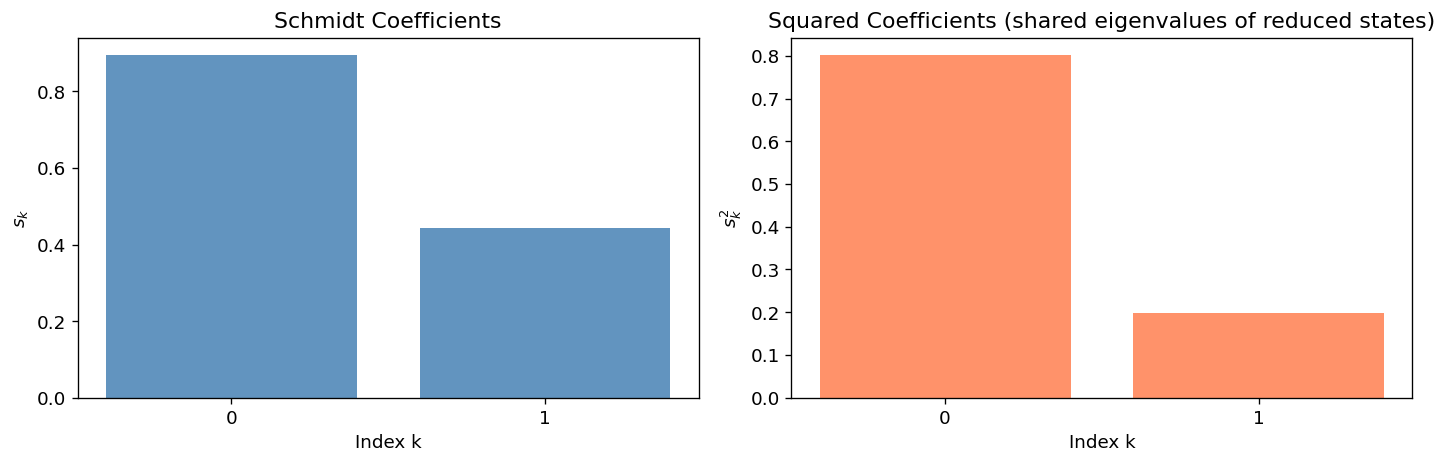

Schmidt rank = 2,  sum(s_k^2) = 1.000000


In [8]:
np.random.seed(42)
psi_3q = random_statevector(8).data

coeffs_ab, _, _ = schmidt_decompose(psi_3q, 2, 4)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(coeffs_ab)), coeffs_ab, color='steelblue', alpha=0.85)
axes[0].set_xlabel('Index k')
axes[0].set_ylabel('$s_k$')
axes[0].set_title('Schmidt Coefficients')
axes[0].set_xticks(range(len(coeffs_ab)))

axes[1].bar(range(len(coeffs_ab)), coeffs_ab**2, color='coral', alpha=0.85)
axes[1].set_xlabel('Index k')
axes[1].set_ylabel('$s_k^2$')
axes[1].set_title('Squared Coefficients (shared eigenvalues of reduced states)')
axes[1].set_xticks(range(len(coeffs_ab)))

plt.tight_layout()
plt.show()

print(f"Schmidt rank = {len(coeffs_ab)},  sum(s_k^2) = {np.sum(coeffs_ab**2):.6f}")

### Quantifying entanglement from Schmidt coefficients

The Schmidt decomposition reveals the entanglement of a bipartite pure state at a glance. Several entanglement measures can be computed directly from the Schmidt coefficients $s_k$ (equivalently, from the eigenvalues $\lambda_k = s_k^2$ of the reduced state $\rho_A$):

| Measure | Formula | Range | Meaning |
|---------|---------|-------|---------|
| **Purity** | $\gamma = \operatorname{Tr}(\rho_A^2) = \sum_k \lambda_k^2$ | $[1/d,\; 1]$ | 1 = Bipartite state is product state, $1/d$ = maximally entangled |
| **Linear entropy** | $S_L = 1 - \operatorname{Tr}(\rho_A^2)$ | $[0,\; 1{-}1/d]$ | 0 = product, higher = more entangled |
| **Participation ratio** | $K = 1/\operatorname{Tr}(\rho_A^2)$ | $[1,\; d]$ | Effective number of Schmidt terms contributing |
| **Von Neumann entropy** | $S = -\sum_k \lambda_k \log_2 \lambda_k$ | $[0,\; \log_2 d]$ | Gold standard entanglement measure for bipartite pure states; $log_2d$ means maximally entangled |

> **Key insight:** For a bipartite *pure* state, all these measures depend only on the reduced state's eigenvalues. Since the Schmidt decomposition guarantees both reduced states share the same eigenvalues, it doesn't matter which subsystem we examine.

State                               Rank   Purity  Lin.Ent   Part.R  S(bits)
----------------------------------------------------------------------------
|00> (product)                         1   1.0000   0.0000   1.0000  -0.0000
cos(pi/8)|00>+sin(pi/8)|11>            2   0.7500   0.2500   1.3333   0.6009
|Phi+> (Bell, max entangled)           2   0.5000   0.5000   2.0000   1.0000


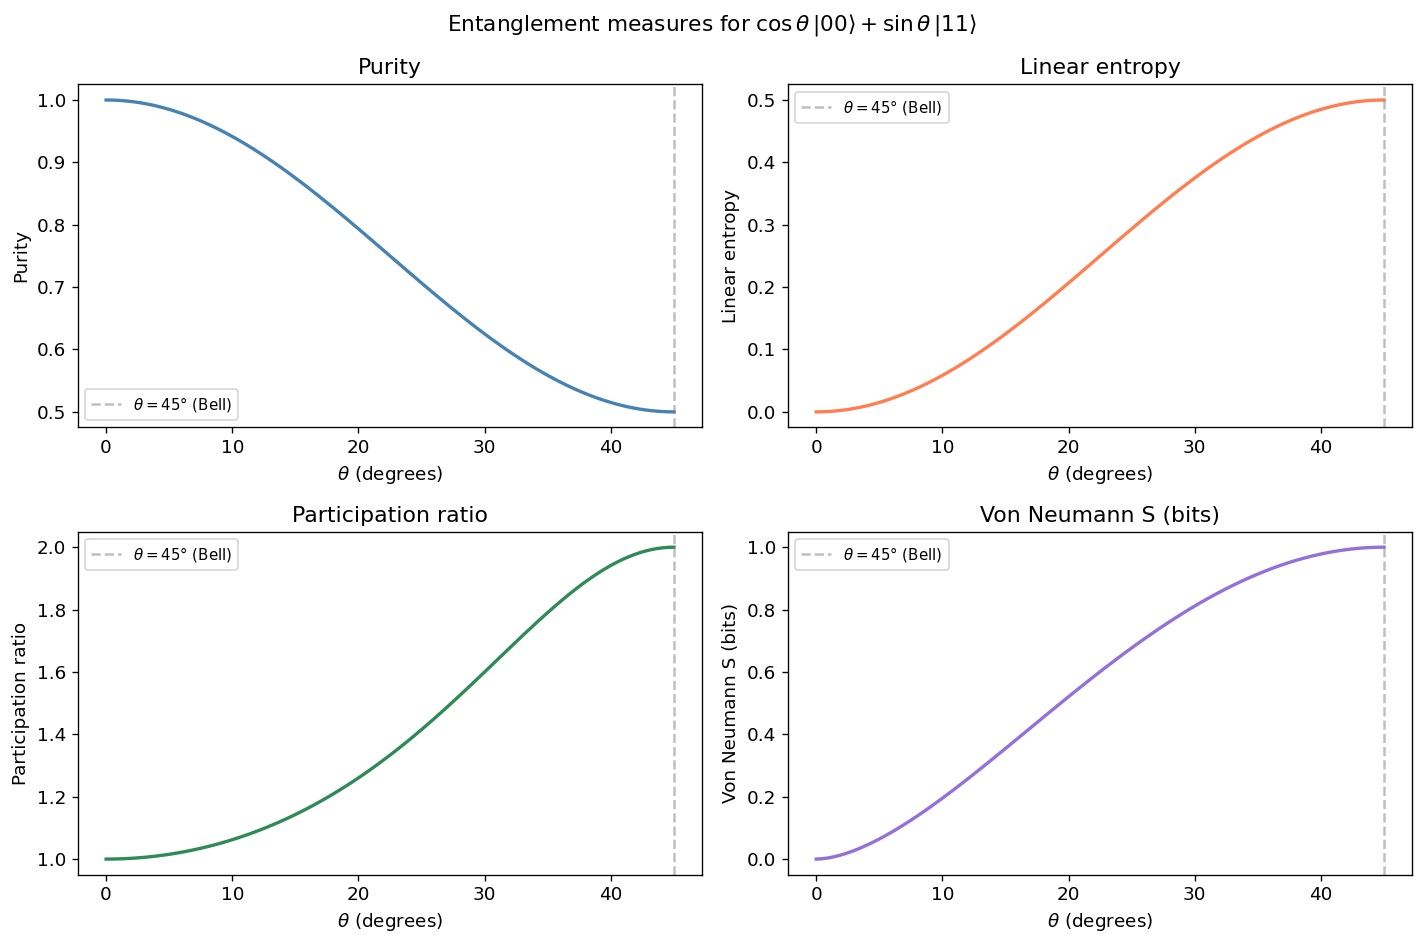

In [9]:
def entanglement_measures(psi, dim_a, dim_b):
    coeffs, _, _ = schmidt_decompose(psi, dim_a, dim_b)
    lambdas = coeffs**2
    purity = np.sum(lambdas**2)
    return {
        'Schmidt rank': len(coeffs),
        'Purity': purity,
        'Linear entropy': 1 - purity,
        'Participation ratio': 1 / purity,
        'Von Neumann S (bits)': -np.sum(lambdas * np.log2(np.maximum(lambdas, 1e-30))),
    }

states = {
    '|00> (product)': np.array([1, 0, 0, 0], dtype=complex),
    'cos(pi/8)|00>+sin(pi/8)|11>': (
        np.cos(np.pi/8) * np.array([1, 0, 0, 0]) +
        np.sin(np.pi/8) * np.array([0, 0, 0, 1], dtype=complex)
    ),
    '|Phi+> (Bell, max entangled)': np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2),
}

header = f"{'State':<34} {'Rank':>5} {'Purity':>8} {'Lin.Ent':>8} {'Part.R':>8} {'S(bits)':>8}"
print(header)
print("-" * len(header))
for name, psi_s in states.items():
    m = entanglement_measures(psi_s, 2, 2)
    print(f"{name:<34} {m['Schmidt rank']:>5d} {m['Purity']:>8.4f} "
          f"{m['Linear entropy']:>8.4f} {m['Participation ratio']:>8.4f} "
          f"{m['Von Neumann S (bits)']:>8.4f}")

thetas_ent = np.linspace(0, np.pi/4, 100)
meas = {k: [] for k in ['Purity', 'Linear entropy', 'Participation ratio', 'Von Neumann S (bits)']}
for th in thetas_ent:
    psi_th = np.array([np.cos(th), 0, 0, np.sin(th)], dtype=complex)
    m = entanglement_measures(psi_th, 2, 2)
    for k in meas:
        meas[k].append(m[k])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = ['steelblue', 'coral', 'seagreen', 'mediumpurple']
for ax, (title, vals), color in zip(axes.flat, meas.items(), colors):
    ax.plot(np.degrees(thetas_ent), vals, color=color, lw=2)
    ax.set_xlabel(r'$\theta$ (degrees)')
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.axvline(45, color='gray', ls='--', alpha=0.5, label=r'$\theta=45°$ (Bell)')
    ax.legend(fontsize=9)

fig.suptitle(r'Entanglement measures for $\cos\theta\,|00\rangle + \sin\theta\,|11\rangle$',
             fontsize=13)
plt.tight_layout()
plt.show()

---

## 3. Unitary Equivalence of Purifications

In Section 1, we saw that $\rho$ has infinitely many purifications. How different can they really be?

The answer is beautifully restrictive: **all purifications of the same $\rho$ differ only by a unitary acting on the ancilla.** The "system" part is identical — only the ancilla's basis changes.

### Theorem

If $|\psi\rangle$ and $|\phi\rangle$ are both purifications of the same $\rho$ (with the same ancilla dimension), there exists a unitary $U$ acting **only on the ancilla** such that

$$(\mathbb{I}_X \otimes U)\,|\psi\rangle = |\phi\rangle.$$

### Proof sketch

1. Write both purifications in Schmidt form.  Both share the same Schmidt coefficients $\sqrt{\lambda_k}$ (eigenvalues of $\rho$) and the same X-basis $\{|x_k\rangle\}$ (eigenvectors of $\rho$).

2. The only difference is the ancilla basis: $|\psi\rangle = \sum_k \sqrt{\lambda_k}\,|x_k\rangle|y_k\rangle$ vs $|\phi\rangle = \sum_k \sqrt{\lambda_k}\,|x_k\rangle|z_k\rangle$.

3. Define $U|y_k\rangle = |z_k\rangle$ and extend unitarily.  Then $(\mathbb{I}\otimes U)|\psi\rangle = |\phi\rangle$.

> **Physical meaning:** All purifications of a given state are physically equivalent — they differ only by a "relabelling" (unitary rotation) of the ancilla. This will be crucial for Uhlmann's theorem in Section 5.

In [10]:
psi_1 = purify(rho)
psi_2 = psi_alt

d = 2
M1 = psi_1.reshape(d, d)
M2 = psi_2.reshape(d, d)

# (I ⊗ U)|ψ₁⟩ = |ψ₂⟩  means  M₂ = M₁ @ Uᵀ,  so  Uᵀ = M₁⁻¹ M₂
U_anc_T = np.linalg.solve(M1, M2)
U_ancilla = U_anc_T.T

print("Connecting unitary on ancilla Y:")
print(U_ancilla.round(4))
print(f"Is unitary: {np.allclose(U_ancilla @ U_ancilla.conj().T, np.eye(d))}")

psi_2_check = np.kron(np.eye(d), U_ancilla) @ psi_1
print(f"\n(I_X ⊗ U)|psi_1> = |psi_2>: {np.allclose(psi_2_check, psi_2)}")

Connecting unitary on ancilla Y:
[[-0.7071-0.j  0.7071+0.j]
 [-0.7071-0.j -0.7071-0.j]]
Is unitary: True

(I_X ⊗ U)|psi_1> = |psi_2>: True


---

## 4. Fidelity

We now turn to a different but related question: **how do we quantify the similarity between two quantum states?**

For classical probability distributions, the **Bhattacharyya coefficient** $\text{BC}(p,q) = \sum_x \sqrt{p(x)\,q(x)}$ measures overlap. Fidelity is its quantum generalisation, with the added subtlety that quantum states can have coherences (off-diagonal terms in the density matrix).

### Definition

The **fidelity** between density matrices $\rho$ and $\sigma$ is

$$F(\rho,\sigma) = \operatorname{Tr}\!\sqrt{\sqrt{\rho}\,\sigma\,\sqrt{\rho}}.$$

Equivalently, $F(\rho,\sigma) = \bigl\|\!\sqrt{\rho}\;\sqrt{\sigma}\,\bigr\|_1$ (trace norm).

> **Convention alert — F vs F²:** Two conventions coexist in the literature:
>
> | Convention | Formula | Used by |
> |------------|---------|---------|
> | **Root fidelity** | $F = \operatorname{Tr}\!\sqrt{\sqrt{\rho}\,\sigma\,\sqrt{\rho}}$ | Watrous, IBM Quantum course, **this notebook** |
> | **Squared fidelity** | $F^2 = \Bigl(\operatorname{Tr}\!\sqrt{\sqrt{\rho}\,\sigma\,\sqrt{\rho}}\Bigr)^{\!2}$ | Jozsa, Nielsen & Chuang, **Qiskit `state_fidelity`** |
>
> Qiskit's `state_fidelity` returns $F^2$. To recover our $F$, take `np.sqrt(state_fidelity(...))`. Both conventions are valid — just be consistent!

### Special cases (root fidelity convention)

| Case | Fidelity |
|-----|-----|
| Both pure: $\rho = \vert \phi \rangle \langle \phi \vert$, $\sigma = \vert \psi \rangle \langle \psi \vert$ | $F = \vert \langle \phi \vert \psi \rangle \vert$ |
| One pure: $\rho = \vert \phi \rangle \langle \phi \vert$ | $F = \sqrt{\langle \phi \vert \sigma \vert \phi \rangle}$ |
| Identical states | $F = 1$ |
| Orthogonal support | $F = 0$ |

### Properties

1. **Bounded:** $0 \leq F(\rho,\sigma) \leq 1$
2. **Symmetric:** $F(\rho,\sigma) = F(\sigma,\rho)$
3. **Multiplicative:** $F(\rho_1\!\otimes\!\rho_2,\;\sigma_1\!\otimes\!\sigma_2) = F(\rho_1,\sigma_1)\cdot F(\rho_2,\sigma_2)$
4. **Monotone under channels:** $F\bigl(\mathcal{N}(\rho),\mathcal{N}(\sigma)\bigr) \geq F(\rho,\sigma)$
5. **Fuchs–van de Graaf:** $1 - F(\rho,\sigma) \;\leq\; \tfrac{1}{2}\|\rho-\sigma\|_1 \;\leq\; \sqrt{1-F(\rho,\sigma)^2}$

> **Interpreting properties 4 and 5:**
>
> - **Monotonicity:** Quantum channels (noise, measurements, any physical process) can never make two states *more* distinguishable. Information is only lost, never created — applying any channel to both states can only increase their fidelity (make them look more alike).
>
> - **Fuchs–van de Graaf:** Fidelity $F$ and trace distance $T = \frac{1}{2}\|\rho-\sigma\|_1$ are tightly linked — knowing one bounds the other from both sides. If $F \approx 1$ then $T \approx 0$ (close in fidelity implies close in trace distance), and vice versa. They give consistent answers about state distinguishability despite being defined very differently.

### Pure-state fidelity

For pure states, fidelity reduces to the absolute value of the inner product — the simplest case. Let's verify with $|0\rangle$ and $|+\rangle$.

In [11]:
phi = Statevector([1, 0])
psi_f = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])

F_inner = np.abs(phi.data @ psi_f.data.conj())
F_qiskit_sq = state_fidelity(phi, psi_f)

print("=== Pure-state fidelity: F(|0>, |+>) ===\n")
print(f"  |<phi|psi>|           (F)  = {F_inner:.6f}")
print(f"  |<phi|psi>|^2         (F²) = {F_inner**2:.6f}")
print(f"  Qiskit state_fidelity (F²) = {F_qiskit_sq:.6f}")
print(f"  sqrt(Qiskit)          (F)  = {np.sqrt(F_qiskit_sq):.6f}")
print(f"\n  Manual F² matches Qiskit F²: {np.isclose(F_inner**2, F_qiskit_sq)}")

=== Pure-state fidelity: F(|0>, |+>) ===

  |<phi|psi>|           (F)  = 0.707107
  |<phi|psi>|^2         (F²) = 0.500000
  Qiskit state_fidelity (F²) = 0.500000
  sqrt(Qiskit)          (F)  = 0.707107

  Manual F² matches Qiskit F²: True


### Mixed-state fidelity

For general mixed states, we must use the full matrix formula. Let's verify our manual implementation against Qiskit and confirm that fidelity is symmetric.

In [12]:
rho = np.array([[3/4, 1/4], [1/4, 1/4]])
sigma = np.array([[1/2, 0], [0, 1/2]])

F_manual = fidelity_manual(rho, sigma)
F_qiskit_sq = state_fidelity(DensityMatrix(rho), DensityMatrix(sigma))

print("=== Mixed-state fidelity: F(rho, sigma) ===\n")
print(f"  Manual Tr[...]         (F)  = {F_manual:.6f}")
print(f"  Manual squared         (F²) = {F_manual**2:.6f}")
print(f"  Qiskit state_fidelity  (F²) = {F_qiskit_sq:.6f}")
print(f"  sqrt(Qiskit)           (F)  = {np.sqrt(F_qiskit_sq):.6f}")
print(f"\n  Manual F² matches Qiskit F²: {np.isclose(F_manual**2, F_qiskit_sq)}")

F_rev = fidelity_manual(sigma, rho)
print(f"\n  Symmetry: F(sigma, rho) = {F_rev:.6f}")
print(f"  F(rho,sigma) == F(sigma,rho): {np.isclose(F_manual, F_rev)}")

=== Mixed-state fidelity: F(rho, sigma) ===

  Manual Tr[...]         (F)  = 0.923880
  Manual squared         (F²) = 0.853553
  Qiskit state_fidelity  (F²) = 0.853553
  sqrt(Qiskit)           (F)  = 0.923880

  Manual F² matches Qiskit F²: True

  Symmetry: F(sigma, rho) = 0.923880
  F(rho,sigma) == F(sigma,rho): True


### Fidelity vs trace distance

How does fidelity relate to the **trace distance**? Both measure state distinguishability but are defined very differently.

**Trace distance** is defined as:

$$T(\rho,\sigma) = \frac{1}{2}\|\rho-\sigma\|_1 = \frac{1}{2}\sum_k |\lambda_k(\rho-\sigma)|$$

where $\|A\|_1 = \operatorname{Tr}\!\sqrt{A^\dagger A}$ is the **trace norm** (sum of singular values). For Hermitian matrices like $\rho - \sigma$, this simplifies to the sum of absolute eigenvalues.

**How it works step by step:**

1. Compute the difference matrix $\Delta = \rho - \sigma$ (Hermitian)
2. Find its eigenvalues $\lambda_k$ (can be positive or negative)
3. Sum their absolute values: $\|\Delta\|_1 = \sum_k |\lambda_k|$
4. Halve the result: $T = \tfrac{1}{2}\|\Delta\|_1$

**Operational meaning:** $T(\rho,\sigma)$ directly determines the optimal probability of correctly distinguishing $\rho$ from $\sigma$ with a single measurement: $p_{\text{success}} = \frac{1}{2}(1 + T)$.

Below we "depolarise" $|0\rangle\langle 0|$ by mixing it with $I/2$: as $p$ decreases from 1 to 0, fidelity drops while trace distance grows.

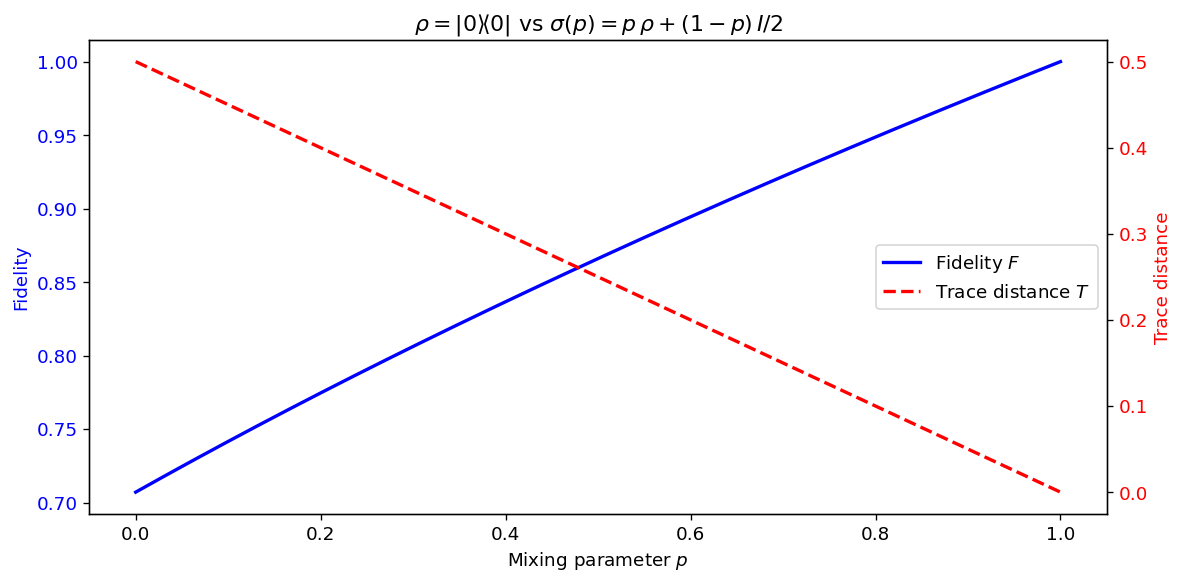

In [ ]:
rho_0 = np.array([[1, 0], [0, 0]], dtype=complex)

ps = np.linspace(0, 1, 200)
F_vals = np.array([fidelity_manual(rho_0, p * rho_0 + (1-p) * np.eye(2)/2) for p in ps])
T_vals = np.array([0.5 * np.linalg.norm(rho_0 - (p * rho_0 + (1-p) * np.eye(2)/2), 'nuc')
                   for p in ps])

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(ps, F_vals, 'b-', lw=2, label='Fidelity $F$')
ax1.set_xlabel('Mixing parameter $p$')
ax1.set_ylabel('Fidelity', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(ps, T_vals, 'r--', lw=2, label='Trace distance $T$')
ax2.set_ylabel('Trace distance', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax1.set_title(r'$\rho = |0\rangle\!\langle 0|$ vs $\sigma(p)=p\,\rho + (1-p)\,I/2$')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.tight_layout()
plt.show()

### Fidelity landscape on the Bloch sphere

How does fidelity vary across all pure qubit states? Below we plot $F(|0\rangle, |\psi(\theta,\phi)\rangle)$ for every point on the Bloch sphere. The reference state $|0\rangle$ sits at the north pole ($\theta=0$) and $|1\rangle$ at the south pole ($\theta=\pi$). Notice that fidelity depends only on $\theta$ (the polar angle), not $\phi$ — as expected from $F = |\langle 0|\psi\rangle| = |\cos(\theta/2)|$.

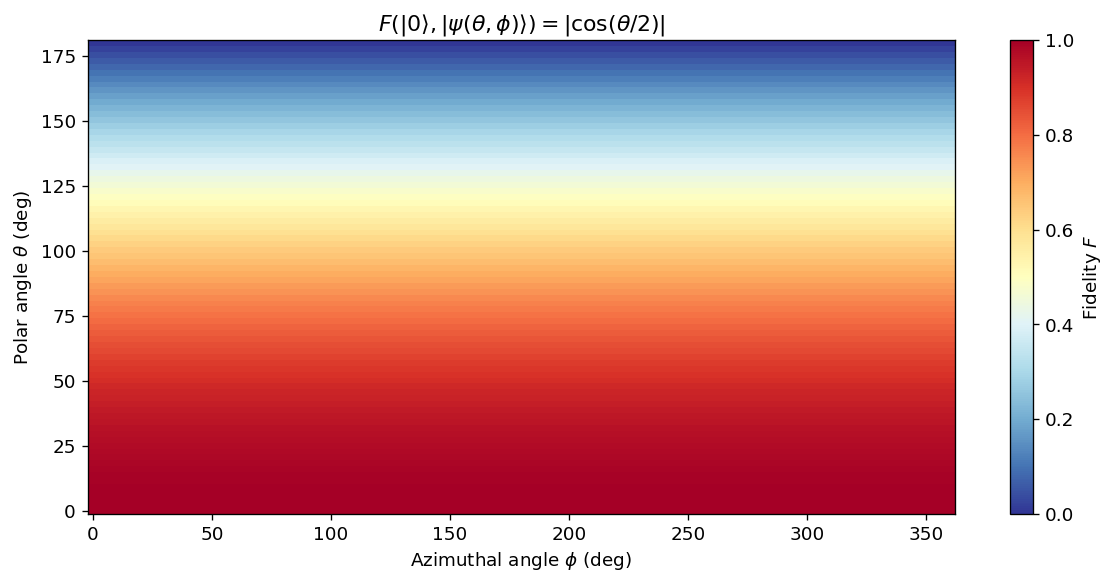

In [14]:
thetas = np.linspace(0, np.pi, 80)
phis_arr = np.linspace(0, 2*np.pi, 80)
THETA, PHI = np.meshgrid(thetas, phis_arr)
F_map = np.zeros_like(THETA)

rho_ref = DensityMatrix(Statevector([1, 0]))
for i in range(len(phis_arr)):
    for j in range(len(thetas)):
        th, ph = THETA[i, j], PHI[i, j]
        sv = Statevector([np.cos(th/2), np.exp(1j*ph)*np.sin(th/2)])
        F_map[i, j] = np.sqrt(state_fidelity(rho_ref, DensityMatrix(sv)))

fig, ax = plt.subplots(figsize=(10, 5))
c = ax.pcolormesh(np.degrees(PHI), np.degrees(THETA), F_map,
                  cmap='RdYlBu_r', shading='auto')
plt.colorbar(c, ax=ax, label='Fidelity $F$')
ax.set_xlabel(r'Azimuthal angle $\phi$ (deg)')
ax.set_ylabel(r'Polar angle $\theta$ (deg)')
ax.set_title(r'$F(|0\rangle, |\psi(\theta,\phi)\rangle) = |\cos(\theta/2)|$')
plt.tight_layout()
plt.show()

---

## 5. Uhlmann's Theorem — The Grand Unification

Everything we've built comes together here. Uhlmann's theorem answers a beautiful question:

> *If fidelity measures how close $\rho$ and $\sigma$ are, can we understand it geometrically in terms of purifications?*

The answer: **yes.** Instead of computing the complicated matrix formula for $F(\rho,\sigma)$, we can purify both states and find the purifications that are as close as possible. The resulting maximum overlap *is* the fidelity.

### Statement

$$F(\rho,\sigma) \;=\; \max\Bigl\{\bigl|\langle\phi|\psi\rangle\bigr| \;:\; \operatorname{Tr}_Y\!\bigl(|\phi\rangle\!\langle\phi|\bigr)=\rho,\;\; \operatorname{Tr}_Y\!\bigl(|\psi\rangle\!\langle\psi|\bigr)=\sigma\Bigr\}.$$

In words: the fidelity between two mixed states equals the **maximum overlap** between any of their purifications.

### Proof sketch

1. Fix purifications $|\psi_\rho\rangle$ and $|\psi_\sigma\rangle$.  Any other purification of $\sigma$ is $(\mathbb{I}\!\otimes\!U)|\psi_\sigma\rangle$ for some unitary $U$ on the ancilla (by Section 3).

2. Reshape each purification into a $d\!\times\!d$ matrix: $M_\rho,\; M_\sigma$.  The overlap becomes $\langle\psi_\rho|(\mathbb{I}\!\otimes\!U)|\psi_\sigma\rangle = \operatorname{Tr}(M_\rho^\dagger\, M_\sigma\, U^T)$.

3. By the SVD of $P = M_\rho^\dagger M_\sigma = W\Sigma V^\dagger$ and von Neumann's trace inequality:

$$\max_U \bigl|\operatorname{Tr}(P\,U^T)\bigr| = \sum_k \sigma_k = \|P\|_1 = \bigl\|\!\sqrt{\rho}\;\sqrt{\sigma}\,\bigr\|_1 = F(\rho,\sigma). \qquad\square$$

> **Why this matters:** Uhlmann's theorem converts a complicated matrix function into a clean geometric optimisation. It also provides the foundation for proving many of fidelity's properties (symmetry, monotonicity, etc.).

### Numerical verification

Let's verify that all four routes to fidelity agree: (1) the matrix formula, (2) Qiskit's built-in, (3) the trace norm $\|P\|_1$, and (4) the actual maximum overlap between optimally-rotated purifications.

In [15]:
rho = np.array([[3/4, 1/4], [1/4, 1/4]])
sigma = np.array([[0.6, 0.1j], [-0.1j, 0.4]])
d = 2

F_formula = fidelity_manual(rho, sigma)
F_qiskit_sq = state_fidelity(DensityMatrix(rho), DensityMatrix(sigma))

psi_rho   = purify(rho)
psi_sigma = purify(sigma)

M_rho   = psi_rho.reshape(d, d)
M_sigma = psi_sigma.reshape(d, d)
P = M_rho.conj().T @ M_sigma

W, s, Vh = np.linalg.svd(P)
F_uhlmann = np.sum(s)

U_opt = W.conj() @ Vh.conj()
psi_sigma_opt = np.kron(np.eye(d), U_opt) @ psi_sigma
overlap = np.abs(psi_rho.conj() @ psi_sigma_opt)

print("=== Four routes to fidelity (root fidelity convention) ===\n")
print(f"  Manual formula     (F)  = {F_formula:.8f}")
print(f"  Qiskit             (F²) = {F_qiskit_sq:.8f}")
print(f"  sqrt(Qiskit)       (F)  = {np.sqrt(F_qiskit_sq):.8f}")
print(f"  ||P||_1 (Uhlmann)  (F)  = {F_uhlmann:.8f}")
print(f"  max |<phi|psi>|    (F)  = {overlap:.8f}")

all_F = [F_formula, np.sqrt(F_qiskit_sq), F_uhlmann, overlap]
print(f"\n  All F values agree: {np.allclose(all_F, F_formula)}")

=== Four routes to fidelity (root fidelity convention) ===

  Manual formula     (F)  = 0.94292974
  Qiskit             (F²) = 0.88911650
  sqrt(Qiskit)       (F)  = 0.94292974
  ||P||_1 (Uhlmann)  (F)  = 0.94292974
  max |<phi|psi>|    (F)  = 0.94292974

  All F values agree: True


### Stress test with random density matrices

A single example is encouraging, but let's test Uhlmann's theorem against 500 random qubit pairs to confirm it holds universally.

In [16]:
np.random.seed(7)
n_trials = 500
max_err = 0.0

for _ in range(n_trials):
    dm_rho = random_density_matrix(2)
    dm_sigma = random_density_matrix(2)

    F_q = np.sqrt(state_fidelity(dm_rho, dm_sigma))

    r, s = dm_rho.data, dm_sigma.data
    psi_r, psi_s = purify(r), purify(s)
    M_r, M_s = psi_r.reshape(2, 2), psi_s.reshape(2, 2)
    sv = np.linalg.svd(M_r.conj().T @ M_s, compute_uv=False)
    F_u = np.sum(sv)

    max_err = max(max_err, abs(F_q - F_u))

print(f"Tested {n_trials} random qubit pairs.")
print(f"Max |sqrt(Qiskit) - Uhlmann| = {max_err:.2e}")
print(f"Uhlmann's theorem verified: {max_err < 1e-10}")

Tested 500 random qubit pairs.
Max |sqrt(Qiskit) - Uhlmann| = 1.55e-15
Uhlmann's theorem verified: True


---

## Summary

### The Conceptual Thread

We followed a natural progression from a basic question to a deep theorem:

1. **Purification** — every mixed state $\rho$ is the "shadow" of a pure state on a larger system
2. **Schmidt decomposition** — the canonical way to write a bipartite pure state, with coefficients = $\sqrt{\text{eigenvalues of } \rho}$
3. **Unitary equivalence** — all purifications of the same $\rho$ differ only by an ancilla rotation
4. **Fidelity** — the quantum measure of state similarity: $F(\rho,\sigma) \in [0,1]$
5. **Uhlmann's theorem** — fidelity = max overlap between purifications (connecting 1–4)

### Key Equations

| Result | Key equation | In words |
|--------|-------------|----------|
| **Purification** | $\|\psi\rangle = \sum_a \sqrt{\lambda_a}\,\|x_a\rangle\|a\rangle$ | Build a pure state from $\rho$'s eigendecomposition; tracing out ancilla recovers $\rho$ |
| **Schmidt decomposition** | $\|\psi\rangle = \sum_k s_k\,\|u_k\rangle\|v_k\rangle$ via SVD | Canonical bipartite form; rank 1 = product (unentangled) state |
| **Unitary equivalence** | $\|\phi\rangle = (\mathbb{I}\otimes U)\|\psi\rangle$ | All purifications of same $\rho$ differ only by ancilla rotation |
| **Fidelity** | $F = \operatorname{Tr}\sqrt{\sqrt{\rho}\,\sigma\,\sqrt{\rho}}$ | State similarity: 0 = perfectly distinguishable, 1 = identical |
| **Uhlmann's theorem** | $F = \max \|\langle\phi\|\psi\rangle\|$ over purifications | Best inner product between any purifications of $\rho$ and $\sigma$ |

> **The overarching theme:** Purification converts mixed-state problems into pure-state problems. Uhlmann's theorem is the prime example — it reduces fidelity (a complicated matrix function) to a simple inner product maximisation.

---

## References

- IBM Quantum Learning — [Purifications and Fidelity: Introduction](https://quantum.cloud.ibm.com/learning/en/courses/general-formulation-of-quantum-information/purifications-and-fidelity/introduction) (John Watrous)

In [22]:
import sys, qiskit, matplotlib

print("--- Disclosure ---")
print("AI tool used - Claude Code (Claude Opus 4.6, Anthropic)")
print("Library versions:")
print(f"  Python     : {sys.version.split()[0]}")
print(f"  Qiskit     : {qiskit.__version__}")
print(f"  NumPy      : {np.__version__}")
print(f"  Matplotlib : {matplotlib.__version__}")

--- Disclosure ---
AI tool used - Claude Code (Claude Opus 4.6, Anthropic)
Library versions:
  Python     : 3.11.5
  Qiskit     : 2.3.0
  NumPy      : 2.3.3
  Matplotlib : 3.10.7
